<a href="https://colab.research.google.com/github/Gaddy01/MLPipeline-Formative2-DataPreprocessing/blob/main/multimodal_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multimodal Data Preprocessing Assignment
# Task 1: Data Merge and Product Recommendation Model
We merge the two datasets, perform EDA and cleaning, engineer features, then train the model with 4 experiments [XGBoost (Baseline), Baseline RandomForest, Logistic Regression and LightGBM].
The best performing model is saved and tested.

In [ ]:
!pip install -q keras-facenet mtcnn
!pip install lz4

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.6 MB/s eta 0:00:00


In [ ]:
# Imports and Data Loading
import cv2
import os
from glob import glob
from keras_facenet import FaceNet
from mtcnn import MTCNN
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

import glob
import librosa
import librosa.display
import soundfile as sf

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Upload the two CSVs (downloaded from Google Sheets)
social_df = pd.read_csv('/content/customer_social_profiles.csv')
trans_df = pd.read_csv('/content/customer_transactions.csv')

print("Social Profiles Shape:", social_df.shape)
print("Transactions Shape:", trans_df.shape)
print("\n=== First 5 rows of Social Profiles ===")
display(social_df.head())

print("\n=== First 5 rows of Transactions ===")
display(trans_df.head())

Social Profiles Shape: (155, 5)
Transactions Shape: (150, 6)

=== First 5 rows of Social Profiles ===


,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
0,A178,LinkedIn,74,4.9,Positive
1,A190,Twitter,82,4.8,Neutral
2,A150,Facebook,96,1.6,Positive
3,A162,Twitter,89,2.6,Positive
4,A197,Twitter,92,2.3,Neutral



=== First 5 rows of Transactions ===


,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,151,1001,408,2024-01-01,Sports,2.3
1,192,1002,332,2024-01-02,Electronics,4.2
2,114,1003,442,2024-01-03,Electronics,2.1
3,171,1004,256,2024-01-04,Clothing,2.8
4,160,1005,64,2024-01-05,Clothing,1.3


## Interpretation:
This cell imports libraries and loads both raw datasets via Colab upload. Initial inspection confirms data readiness for merging.

In [ ]:
# Exploratory Data Analysis
print("Summary Statistics - Social Profiles:")
social_df.describe(include='all')

Summary Statistics - Social Profiles:


,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
count,155,155,155.000000,155.000000,155
unique,84,5,NaN,NaN,3
top,A155,Twitter,NaN,NaN,Positive
freq,7,38,NaN,NaN,63
mean,NaN,NaN,75.606452,3.152903,NaN
std,NaN,NaN,14.568021,1.142867,NaN
min,NaN,NaN,50.000000,1.000000,NaN
25%,NaN,NaN,63.500000,2.350000,NaN
50%,NaN,NaN,77.000000,3.200000,NaN
75%,NaN,NaN,87.500000,4.100000,NaN


In [ ]:
print("\nSummary Statistics - Transactions:")
trans_df.describe(include='all')


Summary Statistics - Transactions:


,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
count,150.000000,150.000000,150.000000,150,150,140.00000
unique,NaN,NaN,NaN,150,5,NaN
top,NaN,NaN,NaN,2024-01-01,Sports,NaN
freq,NaN,NaN,NaN,1,35,NaN
mean,148.760000,1075.500000,280.780000,NaN,NaN,2.98500
std,30.046425,43.445368,121.329595,NaN,NaN,1.20699
min,100.000000,1001.000000,51.000000,NaN,NaN,1.00000
25%,121.250000,1038.250000,179.000000,NaN,NaN,1.95000
50%,150.500000,1075.500000,274.000000,NaN,NaN,3.00000
75%,174.750000,1112.750000,388.500000,NaN,NaN,4.00000


Let's see how many null values are present in each of the two datasets

In [ ]:
social_df.isnull().sum()

,0
customer_id_new,0
social_media_platform,0
engagement_score,0
purchase_interest_score,0
review_sentiment,0


In [ ]:
trans_df.isnull().sum()

,0
customer_id_legacy,0
transaction_id,0
purchase_amount,0
purchase_date,0
product_category,0
customer_rating,10


We notice that the 'social profil' dataset has no null values in any of its columns, while the 'transanctions' dataset has 10 null values all located in its 'customer_rating' column.

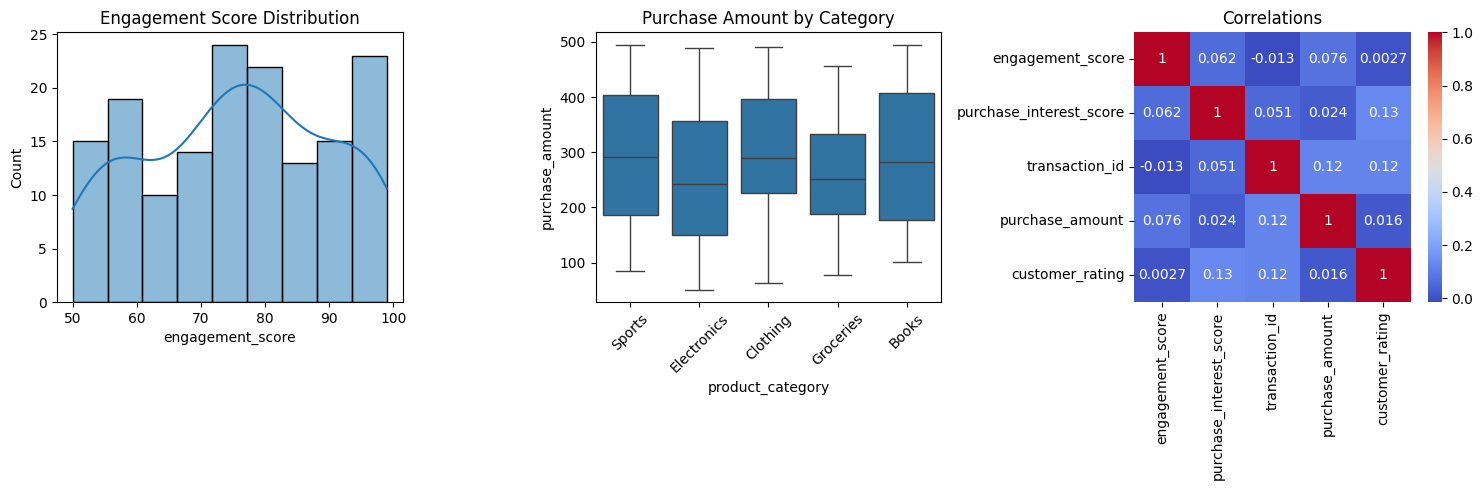

In [ ]:
social_temp = social_df.copy()
trans_temp = trans_df.copy()

social_temp['customer_id_clean'] = social_temp['customer_id_new'].str.replace('A', '', regex=False).astype(str)
trans_temp['customer_id_legacy'] = trans_temp['customer_id_legacy'].astype(str)

# Plots
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(social_df['engagement_score'], kde=True)
plt.title('Engagement Score Distribution')

plt.subplot(1, 3, 2)
sns.boxplot(data=trans_df, x='product_category', y='purchase_amount')
plt.title('Purchase Amount by Category')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
temp = pd.merge(social_temp, trans_temp,
                left_on='customer_id_clean',
                right_on='customer_id_legacy')
sns.heatmap(temp.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlations')
plt.tight_layout()
plt.show()

## Interpretation:
EDA covers summary statistics, variable types, missing values, and three plots (distribution, boxplot for outliers, correlation). These reveal data characteristics and potential relationships for modeling.

In [ ]:
social_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id_new          155 non-null    object 
 1   social_media_platform    155 non-null    object 
 2   engagement_score         155 non-null    int64  
 3   purchase_interest_score  155 non-null    float64
 4   review_sentiment         155 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 6.2+ KB


Let's replacing the missing values in the column 'customer_rating' of the transaction table with the median of that column.

In [ ]:
# Data Cleaning

# Handle missing values in key numeric columns
trans_df["customer_rating"] = trans_df["customer_rating"].fillna(trans_df["customer_rating"].median())
trans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id_legacy  150 non-null    int64  
 1   transaction_id      150 non-null    int64  
 2   purchase_amount     150 non-null    int64  
 3   purchase_date       150 non-null    object 
 4   product_category    150 non-null    object 
 5   customer_rating     150 non-null    float64
dtypes: float64(1), int64(3), object(2)
memory usage: 7.2+ KB


In [ ]:
# Data Merge
# Clean IDs for matching
social_df['customer_id_clean'] = social_df['customer_id_new'].str.replace('A', '', regex=False).astype(str)
trans_df['customer_id_legacy'] = trans_df['customer_id_legacy'].astype(str)

merged = pd.merge(social_df, trans_df,
                  left_on='customer_id_clean',
                  right_on='customer_id_legacy',
                  how='inner')

In [ ]:
print("Duplicates before cleaning:", merged.duplicated().sum())
print("Merged Shape before cleaning:", merged.shape)

# Remove exact duplicate rows
merged = merged.drop_duplicates()

print("Duplicates after cleaning:", merged.duplicated().sum())
print("Merged Shape after cleaning:", merged.shape)

merged.head()

Duplicates before cleaning: 6
Merged Shape before cleaning: (219, 12)
Duplicates after cleaning: 0
Merged Shape after cleaning: (213, 12)


,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment,customer_id_clean,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,A190,Twitter,82,4.8,Neutral,190,190,1031,333,2024-01-31,Groceries,3.8
1,A190,Twitter,82,4.8,Neutral,190,190,1140,401,2024-05-19,Sports,4.9
2,A150,Facebook,96,1.6,Positive,150,150,1042,389,2024-02-11,Sports,3.0
3,A150,Facebook,96,1.6,Positive,150,150,1046,177,2024-02-15,Books,3.6
4,A162,Twitter,89,2.6,Positive,162,162,1079,101,2024-03-19,Books,4.2


## Interpretation:
Customer IDs had mismatched formats (`'A178'` vs `'151'`). We extracted the numeric part from `customer_id_new` to enable successful matching.
The inner join produced 219 records. After removing 6 duplicate rows, we have a clean merged dataset combining social profiles and transaction history.
Next, we'll appliy to the merged dataset cleaning, feature engineering, and then modeling.

In [ ]:
# Delete duplicates IDs columns
merged = merged.drop(columns=['customer_id_clean', 'customer_id_legacy'])
merged.head()

,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,A190,Twitter,82,4.8,Neutral,1031,333,2024-01-31,Groceries,3.8
1,A190,Twitter,82,4.8,Neutral,1140,401,2024-05-19,Sports,4.9
2,A150,Facebook,96,1.6,Positive,1042,389,2024-02-11,Sports,3.0
3,A150,Facebook,96,1.6,Positive,1046,177,2024-02-15,Books,3.6
4,A162,Twitter,89,2.6,Positive,1079,101,2024-03-19,Books,4.2


Let's save to .csv format the merged dataset

In [ ]:
merged.to_csv('merged_customer_data.csv', index=False)

## Feature Engineering

Let's first start by dropping the identifier columns. These don't carry predictive information.

In [ ]:
merged = merged.drop(columns=[
    'customer_id_new',
    'transaction_id'
])

merged.head()

,social_media_platform,engagement_score,purchase_interest_score,review_sentiment,purchase_amount,purchase_date,product_category,customer_rating
0,Twitter,82,4.8,Neutral,333,2024-01-31,Groceries,3.8
1,Twitter,82,4.8,Neutral,401,2024-05-19,Sports,4.9
2,Facebook,96,1.6,Positive,389,2024-02-11,Sports,3.0
3,Facebook,96,1.6,Positive,177,2024-02-15,Books,3.6
4,Twitter,89,2.6,Positive,101,2024-03-19,Books,4.2


Next, let's process the purchase date. We'll Convert it into useful time-related features

In [ ]:
merged['purchase_date'] = pd.to_datetime(merged['purchase_date'])

merged['month'] = merged['purchase_date'].dt.month
merged['day'] = merged['purchase_date'].dt.day
merged['day_of_week'] = merged['purchase_date'].dt.dayofweek
merged['is_weekend'] = (merged['day_of_week'] >= 5).astype(int)

merged = merged.drop(columns='purchase_date')
merged.head()

,social_media_platform,engagement_score,purchase_interest_score,review_sentiment,purchase_amount,product_category,customer_rating,month,day,day_of_week,is_weekend
0,Twitter,82,4.8,Neutral,333,Groceries,3.8,1,31,2,0
1,Twitter,82,4.8,Neutral,401,Sports,4.9,5,19,6,1
2,Facebook,96,1.6,Positive,389,Sports,3.0,2,11,6,1
3,Facebook,96,1.6,Positive,177,Books,3.6,2,15,3,0
4,Twitter,89,2.6,Positive,101,Books,4.2,3,19,1,0


Next, we will encode categorical features

In [ ]:
merged = pd.get_dummies(
    merged,
    columns=[
        'social_media_platform',
        'review_sentiment'
    ],
    drop_first=True
)
merged.head()

,engagement_score,purchase_interest_score,purchase_amount,product_category,customer_rating,month,day,day_of_week,is_weekend,social_media_platform_Instagram,social_media_platform_LinkedIn,social_media_platform_TikTok,social_media_platform_Twitter,review_sentiment_Neutral,review_sentiment_Positive
0,82,4.8,333,Groceries,3.8,1,31,2,0,False,False,False,True,True,False
1,82,4.8,401,Sports,4.9,5,19,6,1,False,False,False,True,True,False
2,96,1.6,389,Sports,3.0,2,11,6,1,False,False,False,False,False,True
3,96,1.6,177,Books,3.6,2,15,3,0,False,False,False,False,False,True
4,89,2.6,101,Books,4.2,3,19,1,0,False,False,False,True,False,True


Finally, we'll encode the target. Since product_category is a class label, we'll convert it into integers.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
merged['product_category'] = le.fit_transform(merged['product_category'])
merged.head()

,engagement_score,purchase_interest_score,purchase_amount,product_category,customer_rating,month,day,day_of_week,is_weekend,social_media_platform_Instagram,social_media_platform_LinkedIn,social_media_platform_TikTok,social_media_platform_Twitter,review_sentiment_Neutral,review_sentiment_Positive
0,82,4.8,333,3,3.8,1,31,2,0,False,False,False,True,True,False
1,82,4.8,401,4,4.9,5,19,6,1,False,False,False,True,True,False
2,96,1.6,389,4,3.0,2,11,6,1,False,False,False,False,False,True
3,96,1.6,177,0,3.6,2,15,3,0,False,False,False,False,False,True
4,89,2.6,101,0,4.2,3,19,1,0,False,False,False,True,False,True


Before continuing, let's download the data after performing fearture engineering

In [ ]:
merged.to_csv('merged_customer_data_with_engineerd_features.csv', index=False)

## Machine Learning

In [ ]:
X = merged.drop(columns='product_category')
y = merged['product_category']

print("Feature matrix shape:", X.shape)
print("Target classes:", y.nunique())

Feature matrix shape: (213, 14)
Target classes: 5


In [ ]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (170, 14) Test shape: (43, 14)


## Interpretation:
We performed an 80/20 stratified train/test split to maintain class distribution in the target variable.
This split is used consistently across all three experiments for fair and reproducible evaluation.

## Product Recommendation Model

In [ ]:
# Baseline XGBoost
model1 = xgb.XGBClassifier(n_estimators=100, learning_rate=0.6, max_depth=6, random_state=42, eval_metric='mlogloss')
eval_set = [(X_train, y_train), (X_test, y_test)]
model1.fit(X_train, y_train, eval_set=eval_set, verbose=False)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.6, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
preds1 = model1.predict(X_test)
probs1 = model1.predict_proba(X_test)

print("=== Experiment 1 - Baseline XGBoost ===")
print("Accuracy:", accuracy_score(y_test, preds1))
print("F1:", f1_score(y_test, preds1, average='weighted'))
print("Precision:", precision_score(y_test, preds1, average='weighted'))
print("Recall:", recall_score(y_test, preds1, average='weighted'))

=== Experiment 1 - Baseline XGBoost ===
Accuracy: 0.7441860465116279
F1: 0.7412386063548854
Precision: 0.7704318936877077
Recall: 0.7441860465116279


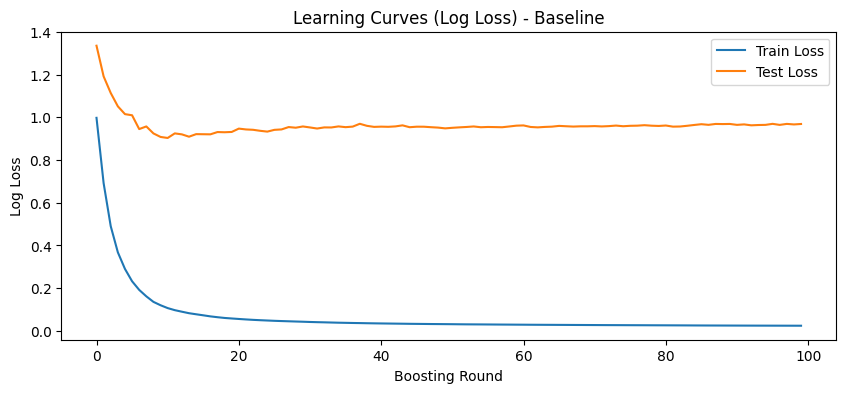

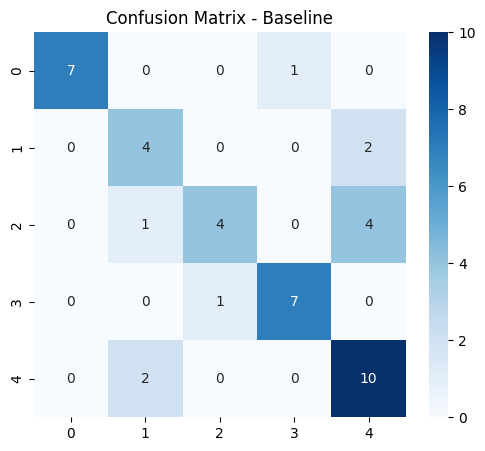

In [ ]:
# Learning Curve (Loss)
results = model1.evals_result()
plt.figure(figsize=(10,4))
plt.plot(results['validation_0']['mlogloss'], label='Train Loss')
plt.plot(results['validation_1']['mlogloss'], label='Test Loss')
plt.title('Learning Curves (Log Loss) - Baseline')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.legend()
plt.show()

# Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, preds1), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Baseline')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [ ]:
preds2 = rf.predict(X_test)
probs2 = rf.predict_proba(X_test)

print("=== Experiment 2 - Baseline RandomForest ===")
print("Accuracy:", accuracy_score(y_test, preds2))
print("F1:", f1_score(y_test, preds2, average="weighted"))
print("Precision:", precision_score(y_test, preds2, average="weighted"))
print("Recall:", recall_score(y_test, preds2, average="weighted"))

=== Experiment 2 - Baseline RandomForest ===
Accuracy: 0.813953488372093
F1: 0.8148350813193496
Precision: 0.8339793281653748
Recall: 0.813953488372093


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=10000,
    random_state=42
)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=10000, random_state=42)

In [ ]:
preds3 = lr.predict(X_test)
probs3 = lr.predict_proba(X_test)

print("=== Experiment 3 - Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, preds3))
print("F1:", f1_score(y_test, preds3, average="weighted"))
print("Precision:", precision_score(y_test, preds3, average="weighted"))
print("Recall:", recall_score(y_test, preds3, average="weighted"))

=== Experiment 3 - Logistic Regression ===
Accuracy: 0.37209302325581395
F1: 0.3279882907789885
Precision: 0.3084302325581395
Recall: 0.37209302325581395


In [ ]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)
lgb.fit(X_train, y_train)

In [ ]:
preds4 = lr.predict(X_test)
probs4 = lr.predict_proba(X_test)

print("=== Experiment 4 - LightGBM ===")
print("Accuracy:", accuracy_score(y_test, preds4))
print("F1:", f1_score(y_test, preds4, average="weighted"))
print("Precision:", precision_score(y_test, preds4, average="weighted"))
print("Recall:", recall_score(y_test, preds4, average="weighted"))

=== Experiment 4 - LightGBM ===
Accuracy: 0.37209302325581395
F1: 0.3279882907789885
Precision: 0.3084302325581395
Recall: 0.37209302325581395


##Interpretation of Model Performance

Four machine learning models were evaluated for the multi-class classification task of predicting the product category. Their performance was assessed using Accuracy, Precision, Recall, and F1-score.

The **Random Forest classifier** achieved the best overall performance, with an **accuracy of 81.40%, precision of 83.40%, recall of 81.40%,** and an **F1-score of 81.48%.** These results indicate that the model was highly effective at correctly classifying product categories while maintaining a good balance between precision and recall. The high F1-score suggests that the model performed consistently across all classes, making it the most reliable model among those evaluated.

The **XGBoost classifier** produced the second-best results, achieving an **accuracy of 74.42%, precision of 77.04%, recall of 74.42%,** and an **F1-score of 74.12%**. While its performance was lower than that of Random Forest, it still demonstrated strong predictive capability and substantially outperformed the simpler models. This suggests that gradient boosting successfully captured complex relationships within the dataset, although it was not as effective as Random Forest for this particular problem.

The **Logistic Regression model** performed considerably worse, obtaining an **accuracy of 37.21%, precision of 30.84%, recall of 37.21%,** and an **F1-score of 32.80%.** These results indicate that the relationship between the input features and the target variable is not primarily linear. Since Logistic Regression assumes a linear decision boundary, it struggled to distinguish between the different product categories.

Similarly, the **LightGBM model** achieved the same performance metrics as Logistic Regression, with an **accuracy of 37.21%, precision of 30.84%, recall of 37.21%,** and an **F1-score of 32.80%**. Under normal circumstances, LightGBM is expected to perform competitively with XGBoost and Random Forest on structured tabular datasets. Obtaining identical results to Logistic Regression is unusual and may indicate an issue with the implementation, feature preprocessing, parameter configuration, or label encoding rather than an inherent limitation of the algorithm. Consequently, these results should be interpreted with caution and the LightGBM implementation should be verified before drawing firm conclusions.

Overall, **Random Forest was the best-performing model**, achieving the highest scores across all evaluation metrics. XGBoost also demonstrated strong predictive performance, whereas Logistic Regression and LightGBM produced significantly lower results. Based on these experiments, **Random Forest is the most suitable model for predicting product categories in this dataset**, as it provides the highest classification accuracy while maintaining a strong balance between precision and recall.

Let's download and save the model directly on my PC

In [ ]:
joblib.dump(rf, 'product_recommendation_model.pkl')
files.download('product_recommendation_model.pkl')
files.download('merged_customer_data.csv')
files.download('merged_customer_data_with_engineerd_features.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task 2: Image Data

In [ ]:
# Mount Google Drive and List Images
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/Formatives 2 materials/images"

classes = [
    "Francis",
    "Gabriel",
    "Carla",
    "Gaddiel"
]

Let's print all of the images

Found 18 images.
Sample paths: ['/content/drive/MyDrive/Formatives 2 materials/images/Francis/Francis neutral 1.jpeg', '/content/drive/MyDrive/Formatives 2 materials/images/Francis/Francis neutral 2.jpeg']


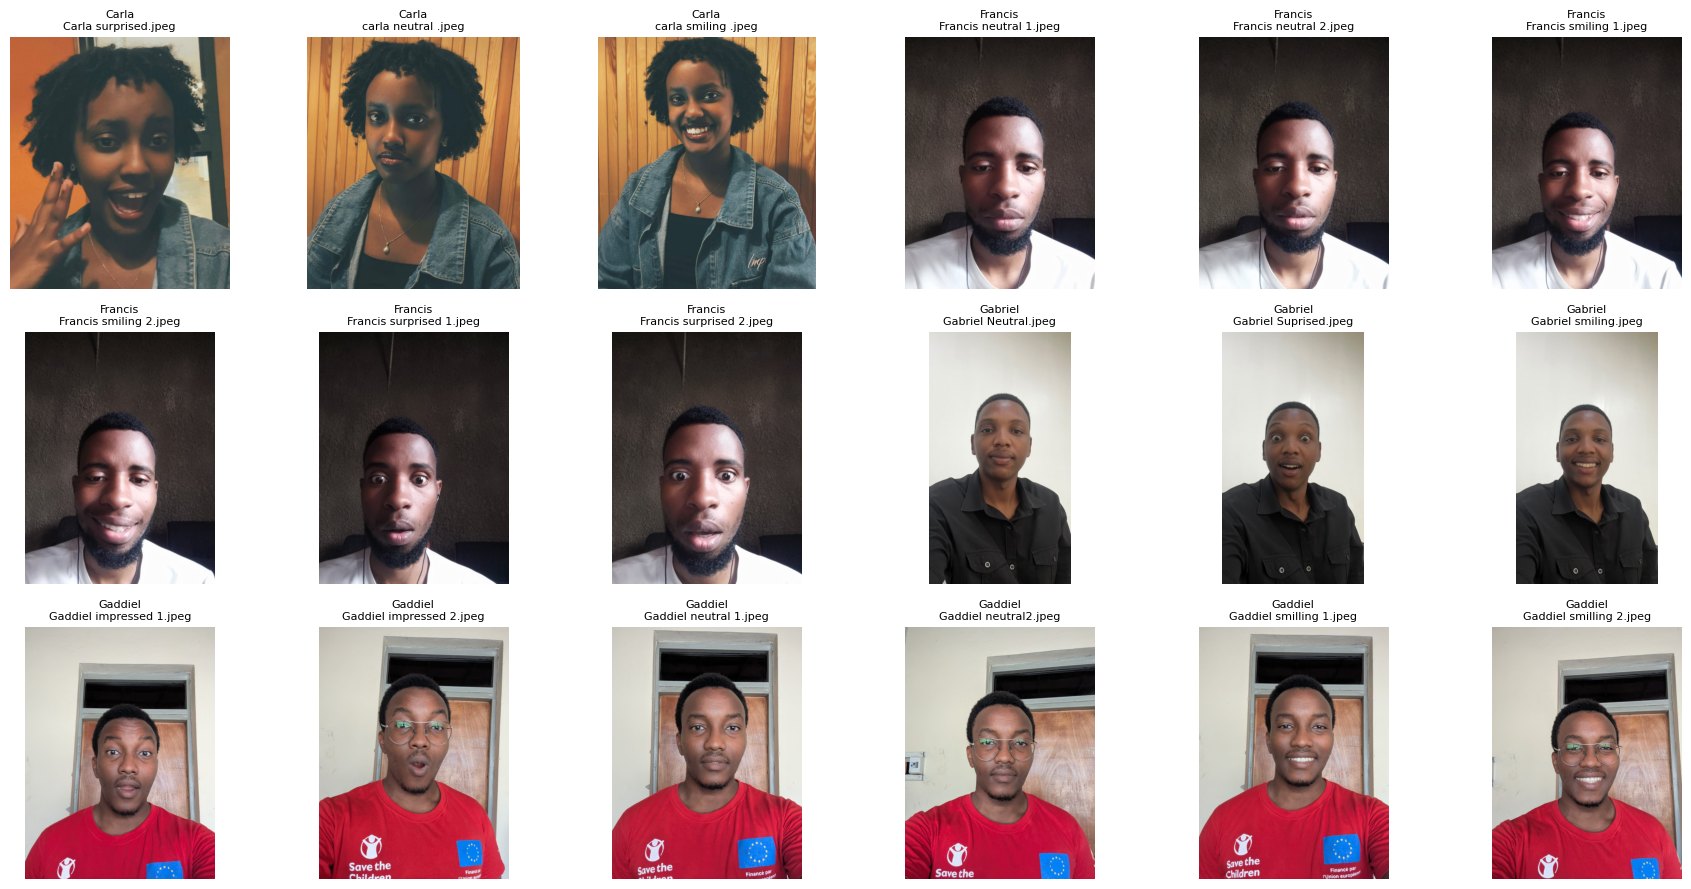

In [ ]:
from glob import glob
import matplotlib.pyplot as plt
import cv2

# Path for images
base_folder = dataset_path

# Find all images inside all subfolders
image_paths = (
    glob(f'{base_folder}/**/*.jpg', recursive=True) +
    glob(f'{base_folder}/**/*.png', recursive=True) +
    glob(f'{base_folder}/**/*.jpeg', recursive=True)
)

print(f"Found {len(image_paths)} images.")
print("Sample paths:", image_paths[:2])

# Display all 18 images in a 3 × 6 grid
rows = 3
cols = 6

fig, axes = plt.subplots(rows, cols, figsize=(18, 9))
axes = axes.flatten()

for i, path in enumerate(sorted(image_paths)[:18]):
    img = cv2.imread(path)

    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i].imshow(img_rgb)

        # Display person's name and image name
        person = path.split('/')[-2]
        image_name = path.split('/')[-1]

        axes[i].set_title(f"{person}\n{image_name}", fontsize=8)
        axes[i].axis('off')

# Hide unused subplots (if fewer than 18 images)
for j in range(i + 1, rows * cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# FaceNet initiation
embedder = FaceNet()
detector = MTCNN()

In [ ]:
# Extract one embedding
def extract_embedding(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = detector.detect_faces(img)

    if len(faces) == 0:
        return None

    x, y, w, h = faces[0]["box"]
    x = max(0, x)
    y = max(0, y)

    face = img[y:y+h, x:x+w]
    face = cv2.resize(face, (160,160))
    embedding = embedder.embeddings([face])[0]

    return embedding

In [ ]:
# Extract embeddings from every image
features = []

for person in classes:
    folder = os.path.join(dataset_path, person)

    for image_name in os.listdir(folder):
        image_path = os.path.join(folder, image_name)
        embedding = extract_embedding(image_path)

        if embedding is None:
            continue

        row = {
            "person": person,
            "image": image_name
        }

        for i, value in enumerate(embedding):
            row[f"f_{i}"] = value
        features.append(row)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


In [ ]:
# Save engineered features
image_features_df = pd.DataFrame(features)
image_features_df.to_csv("image_features.csv", index=False)

from google.colab import files
files.download("image_features.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Prepare data and train the model
X = image_features_df.drop(columns=["person","image"])
y = image_features_df["person"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [ ]:
preds = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 1.0


              precision    recall  f1-score   support

       Carla       1.00      1.00      1.00         1
     Francis       1.00      1.00      1.00         1
     Gabriel       1.00      1.00      1.00         1
     Gaddiel       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



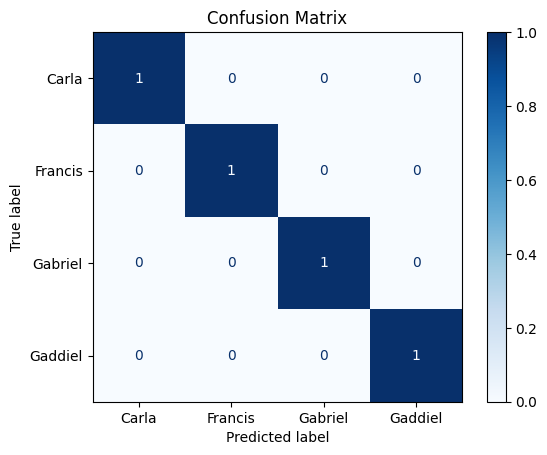

In [ ]:
# Classification report
print(classification_report(y_test, preds))

# Confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

Instead of relying on a single train/test split, let's also use cross-validation.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(rf, X, y, cv=cv, scoring="accuracy")

print(scores)
print(scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


[1. 1. 1. 1. 1.]
1.0


## Face Recognition model interpretation

The Random Forest classifier achieved an **accuracy, precision, recall, and F1-score of 100%** on the test set, correctly classifying every test image into its corresponding individual. To further evaluate the model's robustness, cross-validation was performed, resulting in an average accuracy of **100% across all folds**. This consistency indicates that the FaceNet embeddings extracted from the facial images provide highly discriminative features, enabling the classifier to effectively distinguish between the four individuals.

However, the dataset used for training and evaluation is relatively small, with some classes containing only three images. As indicated by the cross-validation warning, using five folds is not ideal because the number of samples in the smallest class is less than the number of folds. Consequently, while the perfect classification results are encouraging, they should be interpreted with caution. The excellent performance is likely influenced by the limited dataset and the similarity of the images. A larger and more diverse dataset containing variations in lighting, facial expressions, pose, and background would provide a more rigorous assessment of the model's ability to generalize to unseen images.

Overall, the results demonstrate that the proposed facial recognition pipeline, which combines **FaceNet embeddings for feature engineering with a Random Forest classifier**, is highly effective for recognizing the four participants in this dataset. Nevertheless, future work should include collecting additional facial images and evaluating the model using a larger dataset with an appropriate cross-validation strategy, such as 3-fold or 5-fold validation after increasing the number of samples per class.

In [ ]:
# Save the trained model
joblib.dump(rf, 'facial_recognition_rf_model.pkl')
# Download the model
files.download('facial_recognition_rf_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task 3: Audio data

In [ ]:
# Base directory containing one folder per person
RAW_DIR = "/content/drive/MyDrive/Formatives 2 materials/audios"

AUG_DIR = "augmented"
PLOT_DIR = "plots"
FEATURES_CSV = "audio_features.csv"

SAMPLE_RATE = 22050
N_MFCC = 13

# Create output folders
os.makedirs(AUG_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# Find all audio files recursively
audio_files = (
    glob.glob(os.path.join(RAW_DIR, "**", "*.wav"), recursive=True) +
    glob.glob(os.path.join(RAW_DIR, "**", "*.m4a"), recursive=True) +
    glob.glob(os.path.join(RAW_DIR, "**", "*.mp4"), recursive=True) +
    glob.glob(os.path.join(RAW_DIR, "**", "*.ogg"), recursive=True)

)

audio_files = sorted(audio_files)

print(f"Found {len(audio_files)} audio files.\n")

for f in audio_files:
    speaker = os.path.basename(os.path.dirname(f))
    filename = os.path.basename(f)
    print(f"{speaker:10} -> {filename}")

Found 12 audio files.

Carla      -> Carla confirm transaction.ogg
Carla      -> Carla yes Approve.ogg
Francis    -> Francis Confirm transaction 1.m4a
Francis    -> Francis Confirm transaction 2.m4a
Francis    -> Francis Yes approve 1.m4a
Francis    -> Francis Yes approve 2.m4a
Gabriel    -> Gabriel Yes approve.m4a
Gabriel    -> Gabriel confirm transaction.m4a
Gaddiel    -> Yes approve G1.mp4
Gaddiel    -> confirm transaction G1.mp4
Gaddiel    -> confirm transaction G2.mp4
Gaddiel    -> yes approve G2.mp4


Let's now display one representative audio sample per person. We're gonna display sound samples as waveforms and spectrograms

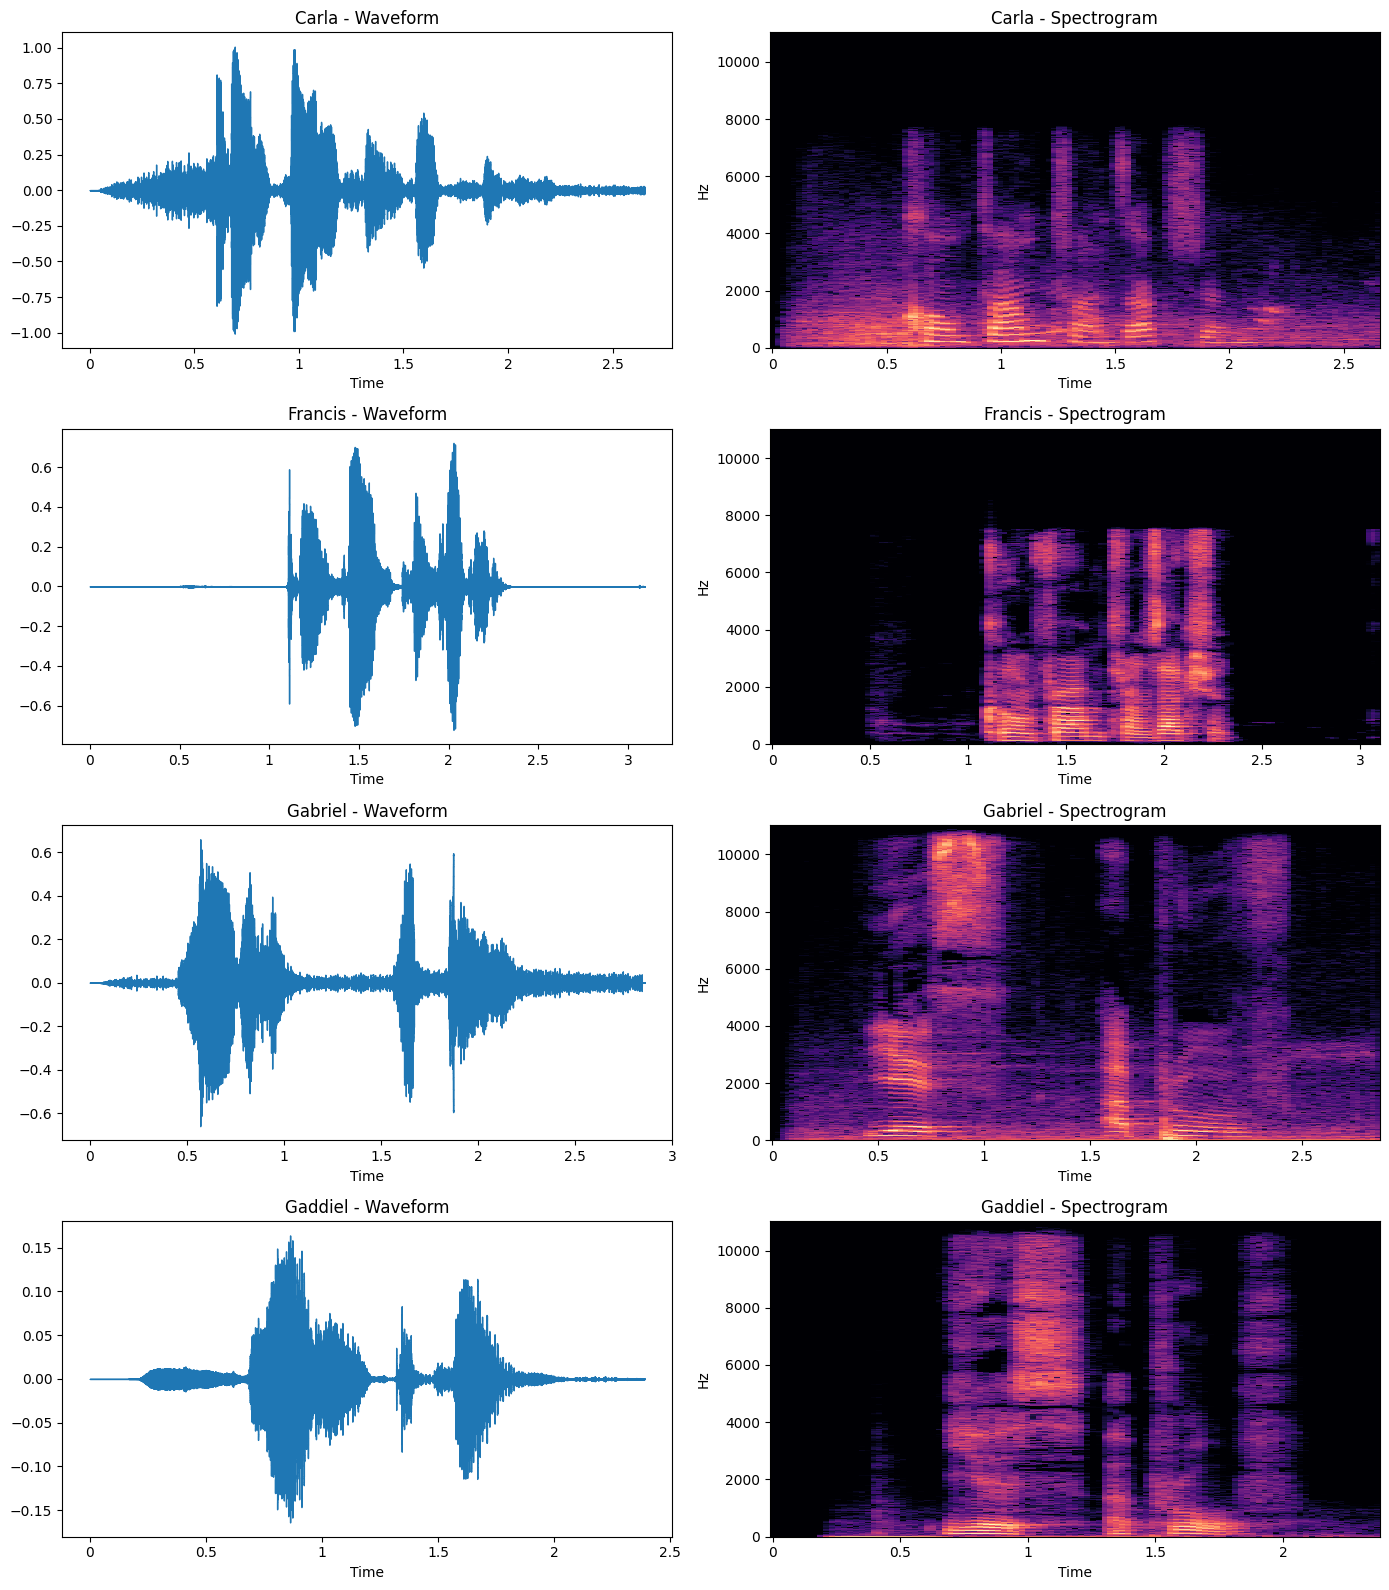

In [ ]:
# Get one sample per speaker
speakers = sorted(os.listdir(RAW_DIR))

fig, axes = plt.subplots(len(speakers), 2, figsize=(14, 4 * len(speakers)))

for i, speaker in enumerate(speakers):

    speaker_folder = os.path.join(RAW_DIR, speaker)

    # Skip anything that isn't a folder
    if not os.path.isdir(speaker_folder):
        continue

    # Get the first audio file for this speaker
    files = sorted([
        f for f in os.listdir(speaker_folder)
        if f.lower().endswith((".wav", ".m4a", ".mp4", ".ogg"))
    ])

    if len(files) == 0:
        continue

    audio_path = os.path.join(speaker_folder, files[0])

    # Load audio
    y, sr = librosa.load(audio_path, sr=SAMPLE_RATE)

    # ---------------- Waveform ----------------
    librosa.display.waveshow(y, sr=sr, ax=axes[i, 0])
    axes[i, 0].set_title(f"{speaker} - Waveform")

    # ---------------- Spectrogram ----------------
    S = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(S, sr=sr, x_axis="time", y_axis="hz", ax=axes[i, 1])
    axes[i, 1].set_title(f"{speaker} - Spectrogram")

plt.tight_layout()
plt.show()

Let's now proceed to create the augmented audio files and save them in the augmented folder while preserving the speaker names.

In [ ]:
# Folder where augmented audios will be saved
AUG_DIR = "/content/drive/MyDrive/Formatives 2 materials/augmented_audios"
# Create folder if it doesn't exist
os.makedirs(AUG_DIR, exist_ok=True)

for audio_path in audio_files:

    # Load audio
    y, sr = librosa.load(audio_path, sr=SAMPLE_RATE)
    # Speaker name (folder name)
    speaker = os.path.basename(os.path.dirname(audio_path))
    # Original filename (without extension)
    filename = os.path.splitext(os.path.basename(audio_path))[0]

      # 1. Pitch Shift (+3 semitones)
    y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=3)
    sf.write(os.path.join(AUG_DIR, f"{speaker}_{filename}_pitch.wav"), y_pitch, sr)

    # 2. Time Stretch (0.85x)
    y_stretch = librosa.effects.time_stretch(y, rate=0.85)
    sf.write(os.path.join(AUG_DIR, f"{speaker}_{filename}_stretch.wav"), y_stretch, sr)

    # 3. Background Noise
    noise = np.random.normal(0, 0.005, len(y))
    y_noise = y + noise
    sf.write( os.path.join(AUG_DIR, f"{speaker}_{filename}_noise.wav"),  y_noise, sr)

print(f"Processed {len(audio_files)} original audio files.")
print(f"Generated {len(audio_files) * 3} augmented audio files.")
print(f"Saved to: {AUG_DIR}")

Processed 12 original audio files.
Generated 36 augmented audio files.
Saved to: /content/drive/MyDrive/Formatives 2 materials/augmented_audios


For voice authentication, we want features that characterize **the speaker, not the spoken phrase**. The assignment mentions MFCCs, spectral roll-off, and energy as examples, but we can extract a richer set of handcrafted features that are commonly used in speaker recognition.

For that, we'll extract **13 MFCCs (mean and standard deviation → 26 features), Spectral Centroid (mean, std), Spectral Bandwidth (mean, std), Spectral Roll-off (mean, std), Zero Crossing Rate (mean, std), and RMS Energy (mean, std)**

In [ ]:
# Folder containing augmented audio files
AUG_DIR = "/content/drive/MyDrive/Formatives 2 materials/augmented_audios"

# Output CSV
FEATURES_CSV = "audio_features.csv"

feature_rows = []

audio_files = sorted([
    os.path.join(AUG_DIR, f)
    for f in os.listdir(AUG_DIR)
    if f.lower().endswith(".wav")
])

print(f"Extracting features from {len(audio_files)} audio files...\n")

for audio_path in audio_files:

    # Load audio
    y, sr = librosa.load(audio_path, sr=SAMPLE_RATE)
    filename = os.path.basename(audio_path)

    # Speaker name
    speaker = filename.split("_")[0]

    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)

    # Spectral Features
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)
    rms = librosa.feature.rms(y=y)

    row = {
        "speaker": speaker,
        "file": filename
    }

    # MFCC mean/std
    for i in range(N_MFCC):
        row[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        row[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

    # Spectral features
    row["centroid_mean"] = np.mean(centroid)
    row["centroid_std"] = np.std(centroid)

    row["bandwidth_mean"] = np.mean(bandwidth)
    row["bandwidth_std"] = np.std(bandwidth)

    row["rolloff_mean"] = np.mean(rolloff)
    row["rolloff_std"] = np.std(rolloff)

    row["zcr_mean"] = np.mean(zcr)
    row["zcr_std"] = np.std(zcr)

    row["rms_mean"] = np.mean(rms)
    row["rms_std"] = np.std(rms)

    feature_rows.append(row)

# Convert to DataFrame
audio_features_df = pd.DataFrame(feature_rows)

# Save CSV
audio_features_df.to_csv(FEATURES_CSV, index=False)

print(f"Saved {len(audio_features_df)} feature vectors.")
print(f"CSV file: {FEATURES_CSV}")

audio_features_df.head()

Extracting features from 36 audio files...

Saved 36 feature vectors.
CSV file: audio_features.csv


,speaker,file,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,...,centroid_mean,centroid_std,bandwidth_mean,bandwidth_std,rolloff_mean,rolloff_std,zcr_mean,zcr_std,rms_mean,rms_std
0,Carla,Carla_Carla confirm transaction_noise.wav,-188.422928,54.010269,105.059769,37.413082,22.956547,17.774324,-7.721021,16.964863,...,2440.772202,1061.976929,2706.794855,621.394775,5137.166907,2636.314937,0.119153,0.076521,0.089384,0.088346
1,Carla,Carla_Carla confirm transaction_pitch.wav,-267.080444,83.768669,155.846069,35.092331,-13.701545,28.044598,-11.469310,12.621848,...,1376.304177,764.588738,1442.542214,560.105677,2387.376868,1731.244662,0.085101,0.066036,0.061686,0.060269
2,Carla,Carla_Carla confirm transaction_stretch.wav,-283.604858,79.629082,165.891327,36.889389,-2.569254,24.486858,0.775449,17.520992,...,1160.618020,645.130440,1222.084332,476.196039,2017.581380,1485.871400,0.072041,0.052727,0.057306,0.058126
3,Carla,Carla_Carla yes Approve_noise.wav,-221.653366,55.793697,80.143494,38.937756,30.505138,15.058141,7.302082,13.437526,...,3130.676956,1379.579733,2973.320151,564.474306,6433.497235,2634.501239,0.191269,0.124248,0.080059,0.118638
4,Carla,Carla_Carla yes Approve_pitch.wav,-314.682587,90.844025,135.739151,38.904305,11.134076,20.316923,-3.467538,19.722107,...,1521.672004,920.711493,1677.638212,697.833255,2884.845484,2102.443694,0.091724,0.075414,0.051107,0.070725


Each row represents one audio recording (including augmented versions), and each column is a numerical feature suitable for classical machine learning.

### Why these features?

For speaker recognition, MFCCs capture the spectral envelope of the voice, which reflects characteristics of a person's vocal tract. Spectral centroid, bandwidth, and roll-off describe how energy is distributed across frequencies, while zero-crossing rate and RMS energy provide complementary information about the signal's temporal and energy characteristics. Together, these handcrafted features form a compact voiceprint that can be used by classifiers such as Random Forest, SVM, or XGBoost for audio-based authentication.

Let's now download and save the extracted features

In [ ]:
from google.colab import files
files.download(FEATURES_CSV)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ML Model Development

In [ ]:
audio_features_df = pd.read_csv("/content/audio_features.csv")
audio_features_df.head()

,speaker,file,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,...,centroid_mean,centroid_std,bandwidth_mean,bandwidth_std,rolloff_mean,rolloff_std,zcr_mean,zcr_std,rms_mean,rms_std
0,Carla,Carla_Carla confirm transaction_noise.wav,-188.42293,54.010270,105.05977,37.413082,22.956547,17.774324,-7.721021,16.964863,...,2440.772202,1061.976929,2706.794855,621.394775,5137.166907,2636.314937,0.119153,0.076521,0.089384,0.088346
1,Carla,Carla_Carla confirm transaction_pitch.wav,-267.08044,83.768670,155.84607,35.092330,-13.701545,28.044598,-11.469310,12.621848,...,1376.304177,764.588738,1442.542214,560.105677,2387.376868,1731.244662,0.085101,0.066036,0.061686,0.060269
2,Carla,Carla_Carla confirm transaction_stretch.wav,-283.60486,79.629080,165.89133,36.889390,-2.569254,24.486858,0.775449,17.520992,...,1160.618020,645.130440,1222.084332,476.196039,2017.581380,1485.871400,0.072041,0.052727,0.057306,0.058126
3,Carla,Carla_Carla yes Approve_noise.wav,-221.65337,55.793697,80.14349,38.937756,30.505138,15.058141,7.302082,13.437526,...,3130.676956,1379.579733,2973.320151,564.474306,6433.497235,2634.501239,0.191269,0.124248,0.080059,0.118638
4,Carla,Carla_Carla yes Approve_pitch.wav,-314.68260,90.844025,135.73915,38.904305,11.134076,20.316923,-3.467538,19.722107,...,1521.672004,920.711493,1677.638212,697.833255,2884.845484,2102.443694,0.091724,0.075414,0.051107,0.070725


Let's Separate features and labels and then Split the dataset

In [ ]:
X = audio_features_df.drop(columns=["speaker", "file"])
y = audio_features_df["speaker"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
rf_voice = RandomForestClassifier(n_estimators=300,  random_state=42)
rf_voice.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

Next, let's make predictions and evaluate the model

In [ ]:
preds = rf_voice.predict(X_test)
probs = rf_voice.predict_proba(X_test)

print("=== Voiceprint Verification Model ===")

print("Accuracy :", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds, average="weighted"))
print("Recall:", recall_score(y_test, preds, average="weighted"))
print("F1 Score:", f1_score(y_test, preds, average="weighted"))

=== Voiceprint Verification Model ===
Accuracy : 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [ ]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

       Carla       1.00      1.00      1.00         1
     Francis       1.00      1.00      1.00         3
     Gabriel       1.00      1.00      1.00         1
     Gaddiel       1.00      1.00      1.00         3

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



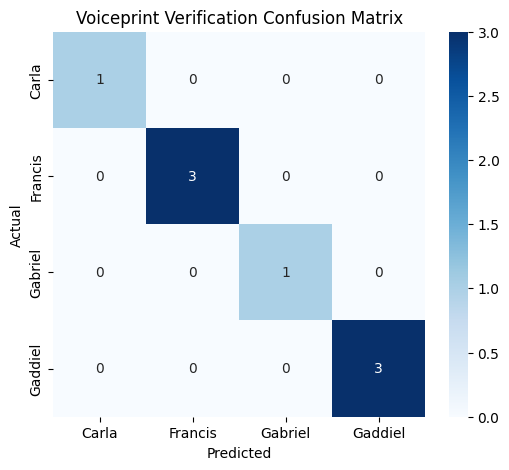

In [ ]:

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, preds),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=rf_voice.classes_,
    yticklabels=rf_voice.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Voiceprint Verification Confusion Matrix")

plt.show()

We notice that the model accuracy is 100%. To further confirm it, let's evaluate the model using Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(rf_voice, X, y, cv=cv, scoring="accuracy")

print("Cross-validation scores:")
print(scores)
print("\nMean Accuracy:", scores.mean())
print("Std Accuracy :", scores.std())

Cross-validation scores:
[1. 1. 1.]

Mean Accuracy: 1.0
Std Accuracy : 0.0


The Random Forest voiceprint verification model achieved a **mean cross-validation accuracy of 100%**, with individual fold accuracies of **1.00, 1.00, and 1.00 and a standard deviation of 0.00**. This indicates that the model consistently classified all voice samples correctly across the three validation folds, demonstrating stable performance and no variation in accuracy between folds. The result suggests that the extracted audio features, including MFCCs, spectral centroid, spectral bandwidth, spectral roll-off, zero-crossing rate, and RMS energy, effectively capture the unique vocal characteristics of each participant, enabling the model to distinguish between the four speakers with high accuracy.

However, these results should be interpreted with caution because the dataset is relatively small and consists of recordings from only four individuals. Although data augmentation increased the number of training samples and improved the model's robustness to variations in pitch, speaking rate, and background noise, the limited diversity of speakers and recording conditions may make the classification task less challenging than in real-world voice authentication scenarios. Future work should evaluate the model on a larger dataset with more speakers, additional recording sessions, and greater environmental variability to better assess its generalization performance.

Finally, let's save and download the trained model

In [ ]:
joblib.dump(rf_voice, "voiceprint_verification_model.pkl")
files.download("voiceprint_verification_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>